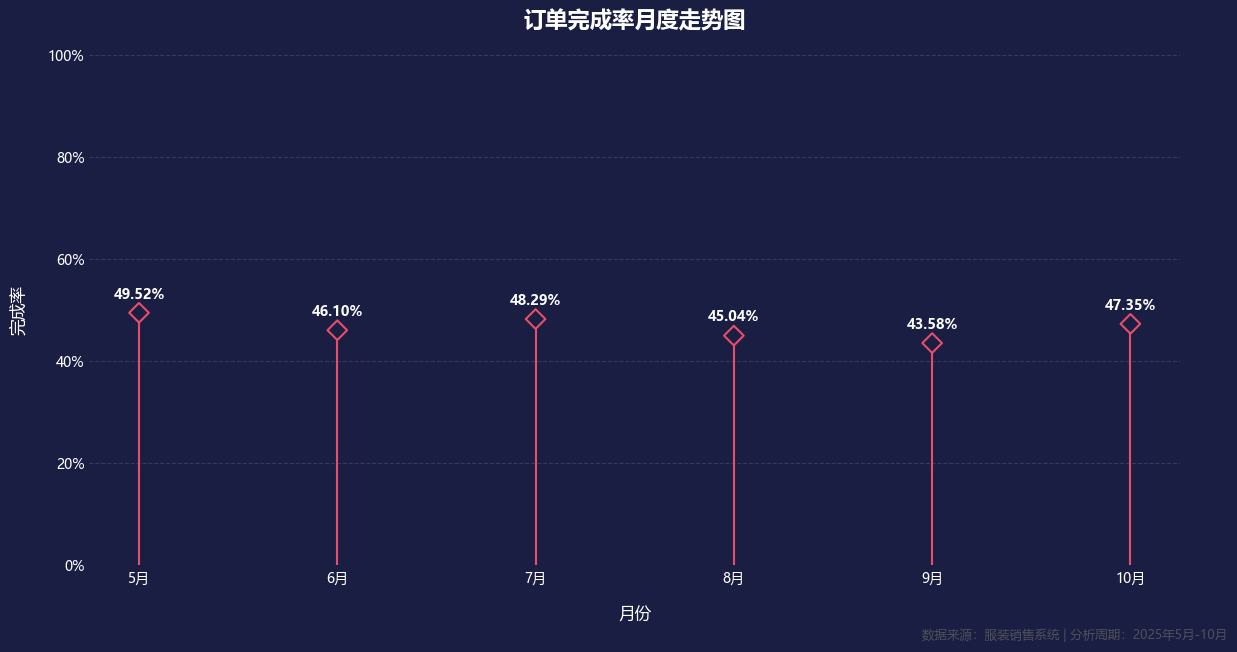

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取订单数据
    df = pd.read_csv("../../erp_order.csv", encoding='utf-8-sig', parse_dates=["下单时间"])
    
    # 验证必要字段
    required_columns = ['下单时间', '状态']
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"数据缺失必要字段: {', '.join(missing_cols)}")
    
    # 检查数据完整性
    if df.empty:
        raise ValueError("订单数据为空")
    if df['状态'].isnull().all():
        raise ValueError("订单状态数据全部为空")
    
    # 数据预处理
    df["月份"] = df["下单时间"].dt.to_period("M").astype(str)
    
    # 计算月度订单完成率
    month_summary = (
        df.groupby("月份")["状态"]
        .value_counts()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # 确保所有状态列存在
    status_columns = ["待付款", "已付款", "已发货", "已完成", "已取消"]
    for s in status_columns:
        if s not in month_summary.columns:
            month_summary[s] = 0
    
    # 计算总订单数和完成率
    month_summary["总订单数"] = month_summary[status_columns].sum(axis=1)
    month_summary["完成率"] = month_summary["已完成"] / month_summary["总订单数"]
    
    # 日期排序处理
    month_summary["月份_dt"] = pd.to_datetime(month_summary["月份"])
    month_summary = month_summary.sort_values("月份_dt")
    
    # 创建图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#1A1E43')  # 深色背景
    ax.set_facecolor('#1A1E43')
    
    # 隐藏坐标轴边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 绘制菱形标记
    plt.scatter(
        month_summary["月份"],
        month_summary["完成率"] * 100,
        edgecolors="#e74e69",
        facecolors='none',
        linewidths=1.5,
        marker="D",
        s=100
    )
    
    # 计算菱形高度（数据坐标系）
    marker_height = 2.5
    
    # 绘制连接线到菱形底部
    for x, y in zip(month_summary["月份"], month_summary["完成率"] * 100):
        bottom_y = max(0, y - marker_height * 3/4)
        plt.plot([x, x], [0, bottom_y], color="#e74e69", linewidth=1.5)
    
    # 添加标题和标签
    plt.title("订单完成率月度走势图", fontsize=16, fontweight="bold", color="#ffffff", pad=20)
    plt.xlabel("月份", fontsize=12, color="#ffffff", labelpad=15)
    plt.ylabel("完成率", fontsize=12, color="#ffffff", labelpad=15)
    
    # 添加数据来源说明
    plt.figtext(
        0.9, 0.03,
        '数据来源：服装销售系统 | 分析周期：2025年5月-10月',
        ha='center', fontsize=9, color='#666666', alpha=0.7
    )
    
    # 配置Y轴
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_locator(mtick.MultipleLocator(20))
    
    # 添加网格线
    ax.grid(axis='y', linestyle="--", alpha=0.3, color='#777b92')
    ax.grid(axis='x', visible=False)
    
    # 添加数据标注
    for x, y in zip(month_summary["月份"], month_summary["完成率"] * 100):
        plt.text(
            x, y + 2,
            f"{y:.2f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            color='white',
            fontweight='bold'
        )
    
    # 设置X轴标签
    ticks = list(range(len(month_summary["月份"])))
    labels = [f"{int(m.split('-')[1])}月" for m in month_summary["月份"]]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    
    # 隐藏刻度线
    ax.tick_params(axis='x', which='both', length=0)
    ax.tick_params(axis='y', which='both', length=0)
    ax.xaxis.set_tick_params(colors='#ffffff')
    ax.yaxis.set_tick_params(colors='#ffffff')
    
    # 调整布局
    plt.tight_layout(rect=(0, 0.03, 1, 0.95))
    
    # 保存图表
    plt.savefig(
        "订单完成率月度走势图.png",
        dpi=300,
        bbox_inches='tight',
        facecolor=fig.get_facecolor()
    )
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析：

- **5月**：
  订单完成率为49.52%，为该时间段内的最高点，表明该月的订单履行效率相对较高。

- **6月**：
  订单完成率下降至46.10%，较5月下降了3.42个百分点，可能与季节性需求变化或供应链挑战有关。

- **7月**：
  订单完成率进一步上升至48.29%，较6月增加了2.19个百分点，显示出订单履行效率的改善。

- **8月**：
  订单完成率略微下降至45.04%，较7月下降了3.25个百分点，可能反映了特定月份的运营压力。

- **9月**：
  订单完成率继续下降至43.58%，较8月下降了1.46个百分点，显示出订单履行效率的持续下滑。

- **10月**：
  订单完成率显著上升至47.35%，较9月增加了3.77个百分点，可能与季节性销售高峰或改进的运营策略有关。


# 结论：

从订单完成率的月度走势分析来看，订单履行效率在5月达到最高点后，经历了几个月的波动，最终在10月显著回升。这种波动可能与市场需求的季节性变化、供应链管理的挑战以及运营策略的调整有关。为了提高订单完成率，企业可能需要优化供应链管理，增强订单处理能力，并根据市场需求变化灵活调整运营策略。